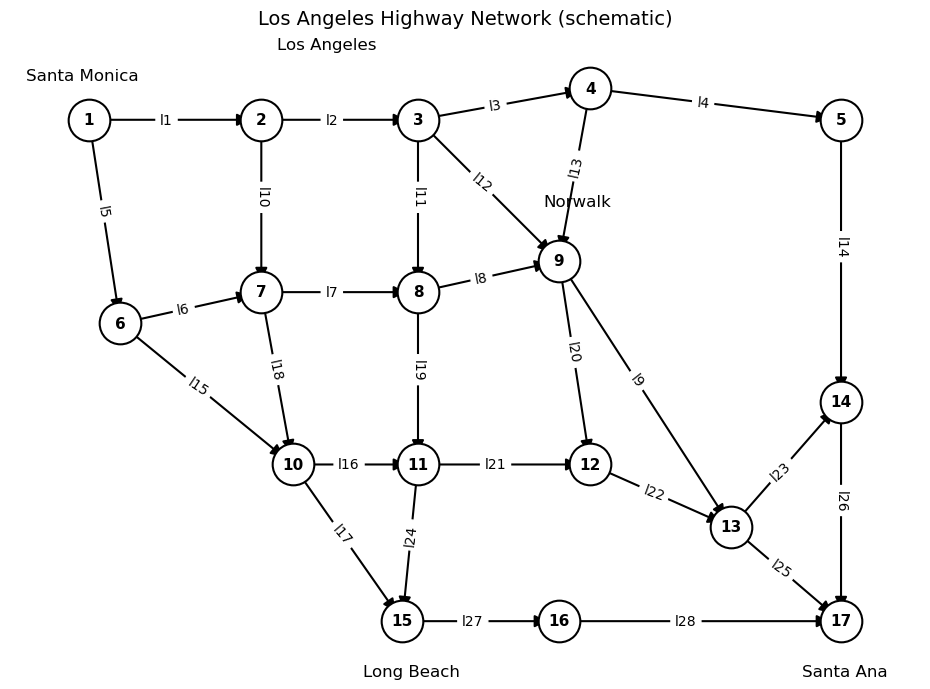

In [ ]:
import scipy.io
f = scipy.io.loadmat('flow.mat')["flow"].reshape(28,)
C = scipy.io.loadmat('capacities.mat')["capacities"].reshape(28,)
B = scipy.io.loadmat('traffic.mat')["traffic"]
l = scipy.io.loadmat('traveltime.mat')["traveltime"].reshape(28,)

import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

# ============================================================
# Build directed graph from the incidence matrix B
# (B rows = nodes, cols = edges; +1 = tail, -1 = head)
# ============================================================
G = nx.DiGraph()
n_nodes, n_edges = B.shape
G.add_nodes_from(range(1, n_nodes + 1))

# Extract (u,v) for each column/edge using the +1/-1 convention
for j in range(n_edges):
    col = B[:, j]
    tail = np.where(col == 1)[0]
    head = np.where(col == -1)[0]
    if len(tail) != 1 or len(head) != 1:
        raise ValueError(f"Incidence error in column {j} (expected one +1 and one -1).")
    u = int(tail[0]) + 1
    v = int(head[0]) + 1
    # Store attributes useful for labels
    G.add_edge(u, v, edge_index=j + 1, time=float(l[j]), capacity=float(C[j]))

# ============================================================
# Node positions chosen to replicate the hand-drawn schematic
# (coordinates are hand-tuned to match the figure)
# ============================================================
pos = {
    1: (-3.2,  2.0),   # Santa Monica (left)
    2: (-2.1,  2.0),
    3: (-1.1,  2.0),
    4: ( 0.0,  2.2),
    5: ( 1.6,  2.0),

    6: (-3.0,  0.7),   # LAX area
    7: (-2.1,  0.9),
    8: (-1.1,  0.9),
    9: (-0.2,  1.1),   # Norwalk
   10: (-1.9, -0.2),
   11: (-1.1, -0.2),
   12: ( 0.0, -0.2),

   15: (-1.2, -1.2),  # Long Beach
   16: (-0.2, -1.2),

   13: ( 0.9, -0.6),
   14: ( 1.6,  0.2),
   17: ( 1.6, -1.2),  # Santa Ana
}

# Safety check: all nodes from B must be placed
missing = set(G.nodes()) - set(pos.keys())
if missing:
    raise RuntimeError(f"Missing coordinates for nodes: {sorted(missing)}")

# ============================================================
# Draw the network with the same visual style of the figure
# ============================================================
plt.figure(figsize=(12, 7))
ax = plt.gca()

# Nodes: white circles with black border
nx.draw_networkx_nodes(
    G, pos, node_size=900, node_color='white',
    edgecolors='black', linewidths=1.5
)

# Directed edges with arrows
nx.draw_networkx_edges(
    G, pos, arrows=True, arrowstyle='-|>',
    arrowsize=18, width=1.5, edge_color='black'
)

# Node labels (numbers)
nx.draw_networkx_labels(G, pos, font_size=11, font_weight='bold')

# Edge labels: l1, l2, ..., l28 (like in the schematic)
edge_labels = {(u, v): f"l{d['edge_index']}" for u, v, d in G.edges(data=True)}
nx.draw_networkx_edge_labels(
    G, pos, edge_labels=edge_labels, font_size=10, label_pos=0.55
)

# Region captions (approximate placements to mirror the figure)
ax.text(-3.6,  2.25, "Santa Monica", fontsize=12)
ax.text(-2.0,  2.45, "Los Angeles", fontsize=12)
ax.text(-0.3,  1.45, "Norwalk", fontsize=12)
ax.text(-1.45, -1.55, "Long Beach", fontsize=12)
ax.text( 1.35, -1.55, "Santa Ana", fontsize=12)

# Final touches
ax.set_title("Los Angeles Highway Network (schematic)", fontsize=14)
ax.set_aspect('equal')
plt.axis('off')
plt.tight_layout()
plt.show()


#### 3.A) Find the shortest path between node 1 and 17. This is equivalent to the fastest path (path with shortest traveling time) in an empty network.


The goal of this exercise is to determine the **shortest path between node 1 and node 17**, which corresponds to the **fastest path** in the highway network under *empty traffic conditions*.  

In this case, each link $e$ of the network is associated with a **delay function** that describes the travel time as a function of the flow $f_e$:

$$
\tau_e(f_e) = \frac{l_e}{1 - \frac{f_e}{c_e}}, \quad 0 \le f_e < c_e
$$

where  
- $l_e$ is the minimum travel time on edge $e$ (the time when the road is empty),  
- $c_e$ is the maximum capacity of the link,  
- $f_e$ is the flow on the link.  

When the network is **empty**, meaning that $f_e = 0$ for every edge, the denominator becomes 1 and the delay function simplifies to the constant value:

$$
\tau_e(0) = l_e
$$

Therefore, under empty conditions, the total travel time along a path $P$ that connects the origin (node 1) and the destination (node 17) is simply the sum of the minimum travel times along all links in that path:

$$
T(P) = \sum_{e \in P} l_e
$$

Finding the **fastest path** is thus equivalent to minimizing this total travel time.  

This can be formulated as a **linear optimization problem**.  
Let $B$ be the **node–edge incidence matrix**, where each column represents one directed edge $e_j$ and each row corresponds to a node. The entry $B_{ij}$ is defined as:

$$
B_{ij} =
\begin{cases}
+1 & \text{if node } i \text{ is the tail of edge } e_j, \\
-1 & \text{if node } i \text{ is the head of edge } e_j, \\
0  & \text{otherwise.}
\end{cases}
$$

We introduce a vector $f \in \mathbb{R}^{m}$, where $f_j$ represents the flow on edge $e_j$.  
The **flow conservation** constraint can be expressed as:

$$
B f = \nu
$$

where $\nu \in \mathbb{R}^{n}$ is the vector of external inflows and outflows:
$$
\nu_i =
\begin{cases}
+1 & \text{if } i = 1 \text{ (origin node)},\\
-1 & \text{if } i = 17 \text{ (destination node)},\\
0  & \text{otherwise.}
\end{cases}
$$

The optimization variable $f$ must be nonnegative ($f \ge 0$) because the flow on each link cannot be negative.  
The objective is to minimize the **total travel time** over all links:

$$
\min_{f \ge 0} \; l^\top f
$$

subject to the flow conservation constraint $Bf = \nu$.  

Hence, the complete linear program can be written as:

$$
\begin{aligned}
\min_{f \in \mathbb{R}^{m}} \quad & l^\top f \\
\text{s.t.} \quad & B f = \nu, \\
& f \ge 0
\end{aligned}
$$

The vector $f^*$ that solves this problem indicates which edges belong to the shortest path:  
for all $e_j$ in the optimal path, $f_j^* = 1$, and for all others $f_j^* = 0$.  
The optimal objective value $l^\top f^*$ gives the total travel time (in hours) along the fastest route.  

This formulation is completely equivalent to the classical shortest-path problem, but expressed as a **minimum-cost flow problem** in linear programming form.  
It also provides a direct link with the delay function: when congestion is absent ($f_e = 0$), the delay reduces to $l_e$, making the shortest path under empty conditions the same as the path with minimum total $l_e$.


In [15]:
import numpy as np
import cvxpy as cp

# ======================================================================
# GOAL:
# Solve the shortest-path problem from node 1 to node 17 as a linear program:
#   minimize   l^T f
#   subject to B f = ν,  f >= 0
# where ν has +1 at the source (node 1), -1 at the target (node 17), and 0 elsewhere.
# This uses B (incidence), l (min travel times) already loaded in a previous cell.
# ======================================================================

# Basic sizes from the already-loaded incidence matrix B
n_nodes, n_edges = B.shape

# Build the supply/demand vector ν: +1 at source, -1 at target
source, target = 1, 17
nu = np.zeros(n_nodes)
nu[source - 1] = 1.0
nu[target - 1] = -1.0

# Decision variable: flow on each edge (nonnegative). With unit ν, optimal f will be a 0/1 path.
f_var = cp.Variable(n_edges, nonneg=True)

# Linear objective: minimize total travel time on used edges
objective = cp.Minimize(l @ f_var)

# Flow conservation: B f = ν
constraints = [B @ f_var == nu]

# Solve the LP
prob = cp.Problem(objective, constraints)
opt_val = prob.solve()  

print(f"Optimal objective : {opt_val:.6f}")

# Identify active edges (belonging to the shortest path). Use a small tolerance to ignore numerical noise.
tol = 1e-6
f_opt = np.array(f_var.value).reshape(-1)
active_idx0 = np.where(f_opt > tol)[0]                 # 0-based edge indices
active_idx1 = active_idx0 + 1                          # 1-based edge ids, i.e., e1..e28
print("Active edges (1-based ids):", active_idx1.tolist())

# ----------------------------------------------------------------------
# Reconstruct the node sequence (path) from the active edges.
# Each column j of B corresponds to one directed edge with:
#   +1 at tail node row,   -1 at head node row.
# We extract (u,v) for each active edge, build a tiny adjacency, and walk from source to target.
# ----------------------------------------------------------------------
# Map every edge j to its (u, v) endpoints in 1-based node labels
tails = np.argmax(B == 1, axis=0)   # row index of +1 for each column j
heads = np.argmax(B == -1, axis=0)  # row index of -1 for each column j
edge_uv = [(int(tails[j]) + 1, int(heads[j]) + 1) for j in range(n_edges)]

# Keep only edges on the optimal path (active)
active_edges_uv = {j: edge_uv[j] for j in active_idx0}

# Build a simple successor map restricted to active edges
succ = {}
for j, (u, v) in active_edges_uv.items():
    succ[u] = v

# Walk from source to target following successors
path_nodes = [source]
cur = source
visited_guard = 0
while cur != target:
    if cur not in succ:
        raise RuntimeError("Reconstruction failed: current node has no outgoing active edge.")
    nxt = succ[cur]
    path_nodes.append(nxt)
    cur = nxt
    visited_guard += 1
    if visited_guard > n_nodes:
        raise RuntimeError("Reconstruction failed: too many steps (cycle suspected).")

print("Shortest (fastest) path (nodes):", path_nodes)

# Compute and print edge-by-edge details and total time as a consistency check
path_edges = list(zip(path_nodes[:-1], path_nodes[1:]))

# Build a lookup from (u,v) -> (edge_id_1based, time)
uv_to_info = {}
for j, (u, v) in enumerate(edge_uv, start=1):
    uv_to_info[(u, v)] = (j, float(l[j-1]))

print("\nPath edges (u, v, edge_id, time_hours):")
path_time_sum = 0.0
for (u, v) in path_edges:
    edge_id, t = uv_to_info[(u, v)]
    path_time_sum += t
    print((u, v, edge_id, t))

print(f"\nPath time sum: {path_time_sum:.6f}  |  From LP objective: {opt_val:.6f}")


Optimal objective : 0.559833
Active edges (1-based ids): [1, 2, 9, 12, 25]
Shortest (fastest) path (nodes): [1, 2, 3, 9, 13, 17]

Path edges (u, v, edge_id, time_hours):
(1, 2, 1, 0.1621)
(2, 3, 2, 0.0554)
(3, 9, 12, 0.10483)
(9, 13, 9, 0.14167)
(13, 17, 25, 0.095833)

Path time sum: 0.559833  |  From LP objective: 0.559833


#### 3.B) Find the maximum flow between node 1 and 17

The goal of this exercise is to determine the **maximum flow** between node 1 and node 17 in the same highway network.  
Each link $e$ has a finite capacity $c_e$, representing the maximum possible flow along that connection.  
The problem can be formulated as a **linear optimization model**, where the objective is to maximize the total flow $F$ sent from the origin to the destination, while respecting flow conservation and capacity constraints.

Let $B$ be the **node–edge incidence matrix**, and let $f \in \mathbb{R}^m$ denote the vector of flows on each edge.  
The **capacity constraint** ensures that no link exceeds its limit:
$$
0 \le f_e \le c_e
$$

The **flow conservation** condition ensures that, for each node, the inflow and outflow are balanced, except for the source and destination:
$$
(Bf)_i =
\begin{cases}
F & \text{if } i = 1 \text{ (source)},\\
-F & \text{if } i = 17 \text{ (sink)},\\
0 & \text{otherwise.}
\end{cases}
$$

Hence, the maximum-flow problem can be written as the following **linear program**:
$$
\begin{aligned}
\max_{f, F} \quad & F \\
\text{s.t.} \quad & B f = \nu(F), \\
& 0 \le f \le c
\end{aligned}
$$

where $\nu(F)$ encodes the net inflow and outflow at the source and sink.  
The optimal value $F^*$ represents the **maximum amount of flow** that can be sent through the network from node 1 to node 17 without violating any capacity limits.  
This formulation is equivalent to the classical maximum-flow problem and produces results consistent with combinatorial algorithms such as Edmonds–Karp.


In [20]:
import cvxpy as cp
import numpy as np

# ======================================================================
# GOAL:
# Compute the maximum flow between node 1 and node 17.
# The formulation uses the incidence matrix B and the capacity vector C.
# ======================================================================

# Basic setup
n_nodes, n_edges = B.shape
source, target = 1, 17

# Variables
f = cp.Variable(n_edges, nonneg=True)  # flow on each edge (must be ≥ 0)
F = cp.Variable()                      # total flow value

# Base conservation constraint: all nodes except source and target must be balanced
# i.e., for all i ≠ source,target : (B @ f)[i] = 0
constraints = []

for i in range(n_nodes):
    if i == source - 1:
        # Outflow from source equals F
        constraints.append((B @ f)[i] == F)
    elif i == target - 1:
        # Inflow to sink equals -F
        constraints.append((B @ f)[i] == -F)
    else:
        # Intermediate nodes: flow conservation
        constraints.append((B @ f)[i] == 0)

# Capacity constraints
constraints.append(f <= C)

# Objective: maximize total flow value F
objective = cp.Maximize(F)

# Solve the linear program
prob = cp.Problem(objective, constraints)
max_flow_value = prob.solve()

# Display results
print(f"Maximum flow from node {source} to node {target}: {max_flow_value:.6f} units")

# Extract optimal edge flows
f_value = np.array(f.value).flatten()

# Print only active edges (those with nonzero flow)
print("\nActive edges (nonzero flow):")
for j, flow_val in enumerate(f_value):
    if flow_val > 1e-6:
        print(f"  e{j+1:>2}: flow = {flow_val:.6f} / capacity = {C[j]:.6f}")


Maximum flow from node 1 to node 17: 22447.999999 units

Active edges (nonzero flow):
  e 1: flow = 8741.000000 / capacity = 8741.000000
  e 2: flow = 7072.885724 / capacity = 9864.000000
  e 3: flow = 5358.531939 / capacity = 13350.000000
  e 4: flow = 3613.731478 / capacity = 10926.000000
  e 5: flow = 13706.999999 / capacity = 13707.000000
  e 6: flow = 6128.956978 / capacity = 6960.000000
  e 7: flow = 5014.670296 / capacity = 7422.000000
  e 8: flow = 3489.572401 / capacity = 6678.000000
  e 9: flow = 3294.237540 / capacity = 6297.000000
  e10: flow = 1668.114275 / capacity = 11102.000000
  e11: flow = 969.898911 / capacity = 8899.000000
  e12: flow = 744.454874 / capacity = 8970.000000
  e13: flow = 1744.800461 / capacity = 9753.000000
  e14: flow = 3613.731478 / capacity = 9719.000000
  e15: flow = 7578.043021 / capacity = 9083.000000
  e16: flow = 4837.713731 / capacity = 7416.000000
  e17: flow = 5522.730247 / capacity = 13353.000000
  e18: flow = 2782.400957 / capacity = 1121

#### 3.C) 

In [22]:
import numpy as np

# ======================================================================
# GOAL:
# Compute the node imbalance vector ν such that B f = ν,
# using the given flow vector f (from flow.mat) and incidence matrix B.
# ======================================================================

# Compute ν = B f
nu = B @ f

# Ensure it's a 1D NumPy array of floats
nu = np.array(nu, dtype=float).flatten()

# Display the result
print("Vector ν (node flow balance):")
for i, val in enumerate(nu, start=1):
    print(f"  Node {i:2d}: {val:10.6f}")

# Optional: check total flow conservation
total_balance = np.sum(nu)
print(f"\nTotal balance (should be 0): {total_balance:.6f}")

# Interpretation:
# Positive ν[i] → net outflow from node i  (source behavior)
# Negative ν[i] → net inflow to node i     (sink behavior)
# Zero ν[i]     → balanced node (internal node)


ValueError: setting an array element with a sequence.